# California Housing Price Prediction using Regression

## Objective

The objective of this assignment is to implement and evaluate different
regression algorithms for predicting median house values using the
California Housing dataset.

The regression models used are:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Support Vector Regressor (SVR)

The models are evaluated using Mean Squared Error (MSE),
Mean Absolute Error (MAE), and R-squared (R²).
Cross-validation and hyperparameter tuning are also performed
to improve and compare model performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Data Loading

The California Housing dataset is obtained using the
`fetch_california_housing()` function from Scikit-learn.

The dataset contains several housing-related features and the target
variable represents the median house value.

In [2]:
housing = fetch_california_housing()

print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [3]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["MedHouseVal"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (20640, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

The dataset was checked for missing values using isnull().sum(). No missing values were found, so no imputation was required.

In [9]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the
distribution of the variables, identify possible outliers, and examine
relationships between the features and the target variable.

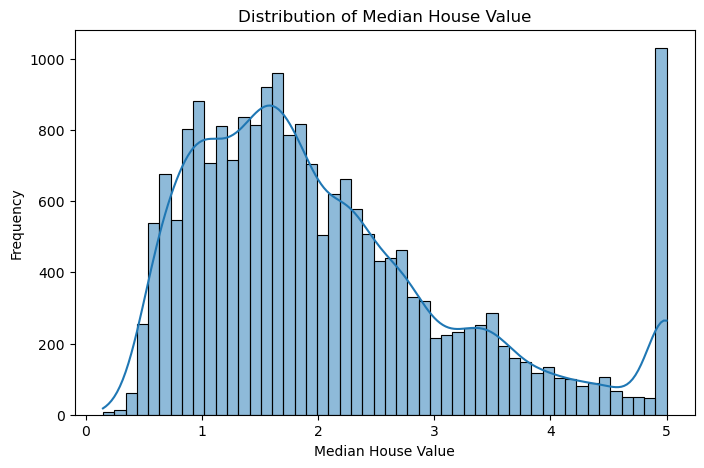

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["MedHouseVal"], bins=50, kde=True)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

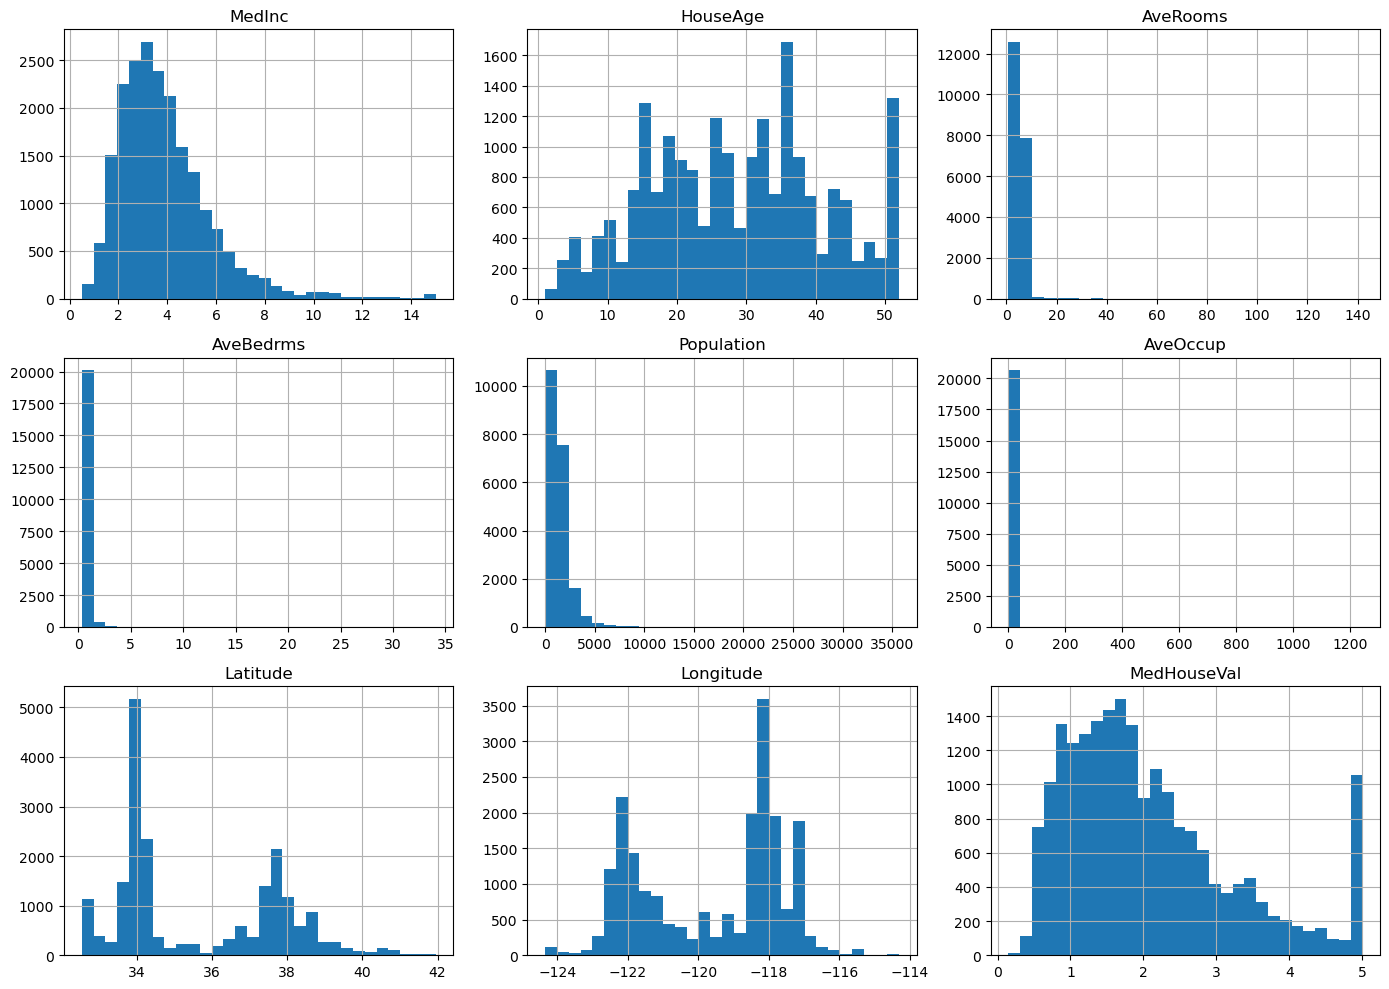

In [11]:
df.hist(figsize=(14, 10), bins=30)

plt.tight_layout()
plt.show()

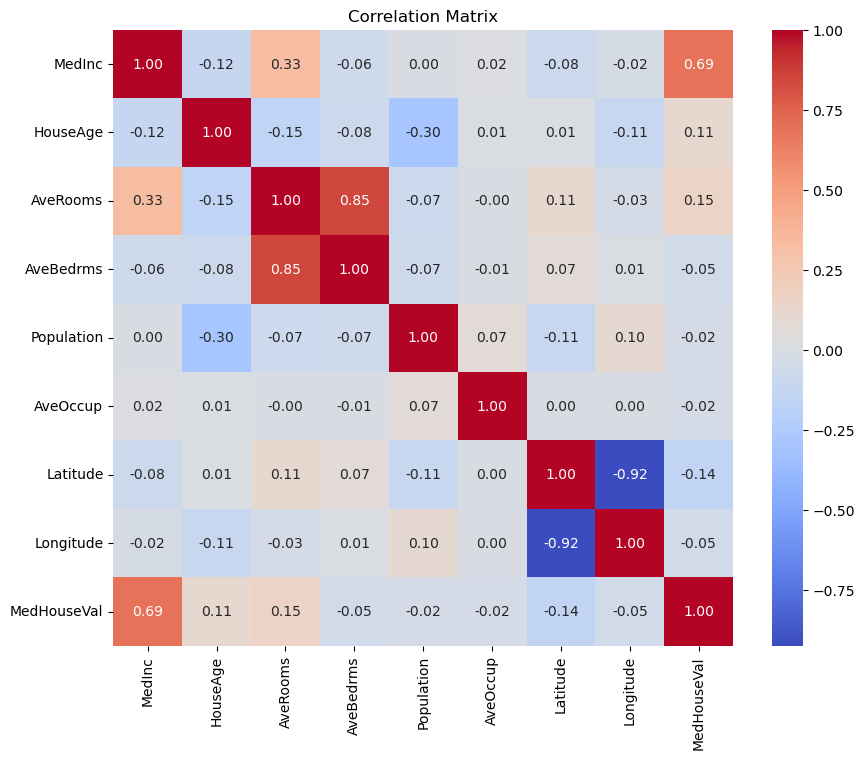

In [12]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
correlation_with_target = df.corr()["MedHouseVal"].sort_values(
    ascending=False
)

print(correlation_with_target)


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


## 3. Data Preprocessing

The dataset is divided into training and testing sets. The training
set is used to train the regression models, while the testing set is
used to evaluate their performance on unseen data.

An 80:20 split is used.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Standardization was applied using StandardScaler so that features have approximately zero mean and unit variance. Scaling is particularly important for distance-based and optimization-based algorithms such as SVR and Linear Regression. The scaler was fitted only on the training data and then applied to the test data to avoid data leakage.

## 4. Regression Algorithms

### 4.1 Linear Regression

Linear Regression models the relationship between the input features
and the target variable using a linear equation.

It is suitable as a baseline model because it is simple,
interpretable, and provides a reference against which more complex
models can be compared.

In [16]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

In [17]:
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MSE:", mse_linear)
print("MAE:", mae_linear)
print("R2 Score:", r2_linear)

Linear Regression
MSE: 0.5558915986952442
MAE: 0.5332001304956566
R2 Score: 0.575787706032451


### 4.2 Decision Tree Regressor

A Decision Tree Regressor recursively divides the data into groups
using feature-based conditions and predicts a numerical value for
each resulting region.

Decision trees can capture nonlinear relationships and do not require
feature scaling.

In [18]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [19]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor")
print("MSE:", mse_dt)
print("MAE:", mae_dt)
print("R2 Score:", r2_dt)

Decision Tree Regressor
MSE: 0.495235205629094
MAE: 0.45467918846899225
R2 Score: 0.622075845135081


### 4.3 Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines
multiple decision trees and averages their predictions.

It can model nonlinear relationships and is generally more robust
than a single decision tree.

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [21]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MSE:", mse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)

Random Forest Regressor
MSE: 0.2553684927247781
MAE: 0.32754256845930246
R2 Score: 0.8051230593157366


### 4.4 Gradient Boosting Regressor

Gradient Boosting builds an ensemble of weak prediction models
sequentially. Each new model attempts to reduce the errors made by
the previous models.

It is suitable for this dataset because it can capture complex
nonlinear relationships between housing features and house values.

In [22]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [23]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor")
print("MSE:", mse_gb)
print("MAE:", mae_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Regressor
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R2 Score: 0.7756446042829697


### 4.5 Support Vector Regressor

Support Vector Regression attempts to find a function that predicts
the target values while keeping prediction errors within a specified
margin.

SVR is sensitive to feature scale, so standardized features are used.

In [24]:
svr_model = SVR()

svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

In [25]:
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor")
print("MSE:", mse_svr)
print("MAE:", mae_svr)
print("R2 Score:", r2_svr)

Support Vector Regressor
MSE: 0.3570040319338651
MAE: 0.3985990769520539
R2 Score: 0.7275628923016773


In [26]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "MSE": [
        mse_linear,
        mse_dt,
        mse_rf,
        mse_gb,
        mse_svr
    ],
    "MAE": [
        mae_linear,
        mae_dt,
        mae_rf,
        mae_gb,
        mae_svr
    ],
    "R2 Score": [
        r2_linear,
        r2_dt,
        r2_rf,
        r2_gb,
        r2_svr
    ]
})

results

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


In [27]:
from sklearn.model_selection import cross_val_score, KFold

In [28]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 5. Cross-Validation

To obtain a more reliable estimate of model performance, 5-fold
cross-validation is performed.

In 5-fold cross-validation, the dataset is divided into five subsets.
The model is trained on four subsets and validated on the remaining
subset. This process is repeated five times, with each subset being
used once as the validation set.

The R² score is used to compare the models. The mean cross-validation
score provides an overall estimate of model performance.

In [29]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [30]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "SVR": SVR()
}

In [31]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

linear_cv_scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)

print("Linear Regression CV scores:")
print(linear_cv_scores)

print("Mean CV R2:", linear_cv_scores.mean())

Linear Regression CV scores:
[0.60970239 0.60411343 0.6354319  0.60076148 0.60727452]
Mean CV R2: 0.611456745810643


In [32]:
dt_cv_scores = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

print("Decision Tree CV scores:")
print(dt_cv_scores)
print("Mean CV R2:", dt_cv_scores.mean())

Decision Tree CV scores:
[0.5842894  0.64327637 0.59405754 0.59032861 0.57430616]
Mean CV R2: 0.597251615745767


In [33]:
rf_cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest CV scores:")
print(rf_cv_scores)
print("Mean CV R2:", rf_cv_scores.mean())

Random Forest CV scores:
[0.80026513 0.81267592 0.80896493 0.79548993 0.80535215]
Mean CV R2: 0.8045496118330078


In [34]:
gb_cv_scores = cross_val_score(
    GradientBoostingRegressor(
        random_state=42
    ),
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

print("Gradient Boosting CV scores:")
print(gb_cv_scores)
print("Mean CV R2:", gb_cv_scores.mean())

Gradient Boosting CV scores:
[0.78557671 0.78890658 0.79892988 0.77793351 0.78917512]
Mean CV R2: 0.7881043594882453


In [35]:
svr_cv_scores = cross_val_score(
    SVR(),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)

print("SVR CV scores:")
print(svr_cv_scores)
print("Mean CV R2:", svr_cv_scores.mean())

SVR CV scores:
[0.73998829 0.73392035 0.75310725 0.72432565 0.72995793]
Mean CV R2: 0.7362598940067911


In [36]:
cv_results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "Mean CV R2": [
        linear_cv_scores.mean(),
        dt_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean(),
        svr_cv_scores.mean()
    ],
    "Standard Deviation": [
        linear_cv_scores.std(),
        dt_cv_scores.std(),
        rf_cv_scores.std(),
        gb_cv_scores.std(),
        svr_cv_scores.std()
    ]
})

cv_results_df

,Model,Mean CV R2,Standard Deviation
0,Linear Regression,0.611457,0.012359
1,Decision Tree,0.597252,0.023962
2,Random Forest,0.804550,0.006109
3,Gradient Boosting,0.788104,0.006765
4,SVR,0.736260,0.009852


### Cross-Validation Analysis

Five-fold cross-validation was performed on the training dataset to evaluate
the consistency and generalization ability of the regression models.

The mean CV R² represents the average coefficient of determination across
the five validation folds, while the standard deviation indicates how much
the model performance varies between folds.

Random Forest achieved a mean CV R² of approximately 0.8045, while Gradient
Boosting achieved approximately 0.7881. SVR achieved approximately 0.7363.
Linear Regression and Decision Tree achieved mean CV R² values of
approximately 0.6115 and 0.5973 respectively.

These results provide a more reliable comparison than a single train-test
split. However, hyperparameter tuning will be performed next before making
the final model selection.

In [37]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "fit_intercept": [True, False]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    param_grid=lr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV R2:", lr_grid.best_score_)

Best Parameters: {'fit_intercept': True}
Best CV R2: 0.6114839952560993


In [38]:
dt_param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV R2:", dt_grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV R2: 0.7100830403599112


In [39]:
rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2: 0.8046016151500588


In [40]:
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV R2:", gb_grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV R2: 0.8216761946323581


In [41]:
from sklearn.model_selection import RandomizedSearchCV

svr_param_grid = {
    "C": [1, 10, 50, 100],
    "gamma": ["scale", "auto"],
    "epsilon": [0.01, 0.1, 0.2]
}

svr_random = RandomizedSearchCV(
    SVR(),
    param_distributions=svr_param_grid,
    n_iter=6,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

svr_random.fit(X_train_scaled, y_train)

print("Best Parameters:", svr_random.best_params_)
print("Best CV R2:", svr_random.best_score_)

Best Parameters: {'gamma': 'scale', 'epsilon': 0.2, 'C': 50}
Best CV R2: 0.762180819553025


In [42]:
# Predictions from tuned models

lr_tuned_pred = lr_grid.best_estimator_.predict(X_test_scaled)

dt_tuned_pred = dt_grid.best_estimator_.predict(X_test)

rf_tuned_pred = rf_grid.best_estimator_.predict(X_test)

gb_tuned_pred = gb_grid.best_estimator_.predict(X_test)

svr_tuned_pred = svr_random.best_estimator_.predict(X_test_scaled)

In [43]:
tuned_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "MSE": [
        mean_squared_error(y_test, lr_tuned_pred),
        mean_squared_error(y_test, dt_tuned_pred),
        mean_squared_error(y_test, rf_tuned_pred),
        mean_squared_error(y_test, gb_tuned_pred),
        mean_squared_error(y_test, svr_tuned_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_tuned_pred),
        mean_absolute_error(y_test, dt_tuned_pred),
        mean_absolute_error(y_test, rf_tuned_pred),
        mean_absolute_error(y_test, gb_tuned_pred),
        mean_absolute_error(y_test, svr_tuned_pred)
    ],
    "R2 Score": [
        r2_score(y_test, lr_tuned_pred),
        r2_score(y_test, dt_tuned_pred),
        r2_score(y_test, rf_tuned_pred),
        r2_score(y_test, gb_tuned_pred),
        r2_score(y_test, svr_tuned_pred)
    ]
})

tuned_results

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.408405,0.431115,0.688338
2,Random Forest,0.255867,0.327930,0.804743
3,Gradient Boosting,0.237774,0.327401,0.818549
4,SVR,0.313522,0.373005,0.760745


## Final Model Selection

After comparing the five regression models using test-set MSE, MAE and R²,
as well as 5-fold cross-validation and hyperparameter tuning, Gradient
Boosting Regressor showed the strongest overall performance on this dataset.

The tuned Gradient Boosting model achieved a cross-validation R² of
0.8217 and a test R² of 0.8185. It also obtained the lowest test MSE
(0.2378) and MAE (0.3274) among the evaluated models.

The selected Gradient Boosting hyperparameters were:

- learning_rate = 0.1
- max_depth = 4
- n_estimators = 200

Random Forest also performed strongly, achieving a test R² of 0.8047.
However, Gradient Boosting provided higher R² and lower MSE and MAE on the
test set.

Therefore, based on the evaluation results obtained in this experiment,
the tuned Gradient Boosting Regressor was selected as the final model for
the California Housing regression task.

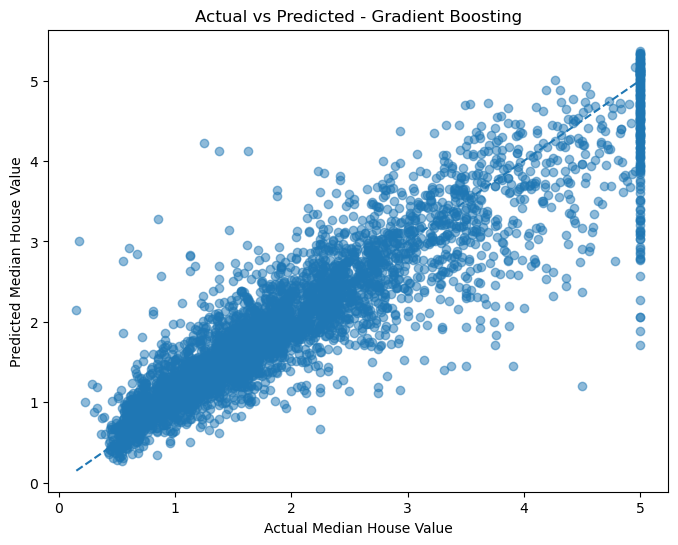

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, gb_tuned_pred, alpha=0.5)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted - Gradient Boosting")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [45]:
residuals = y_test - gb_tuned_pred

print("Mean Residual:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: -0.0070375313045415696
Minimum Residual: -2.967574416670111
Maximum Residual: 3.301613159024809


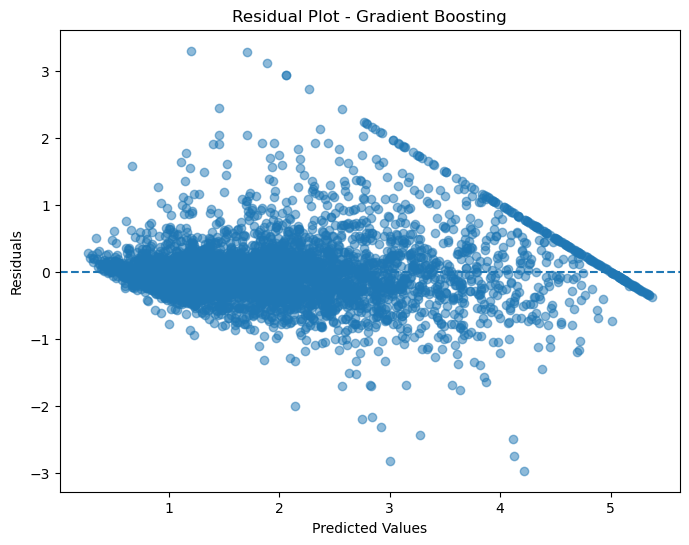

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(gb_tuned_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Gradient Boosting")

plt.show()

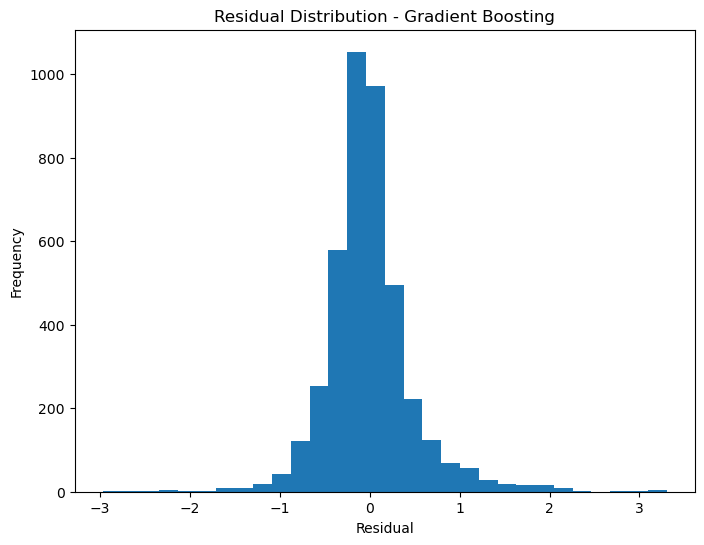

In [47]:
plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Gradient Boosting")

plt.show()

## Final Conclusion

In this project, five regression algorithms were implemented and evaluated on the California Housing dataset: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and Support Vector Regression (SVR).

The models were evaluated using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² score. Five-fold cross-validation was also performed to evaluate the consistency of model performance. Hyperparameter tuning was carried out using GridSearchCV for Linear Regression, Decision Tree, Random Forest, and Gradient Boosting, while RandomizedSearchCV was used for SVR.

The tuned Gradient Boosting Regressor achieved the strongest overall performance. It obtained a cross-validation R² score of **0.8217** and a test R² score of **0.8185**. It also achieved the lowest test MSE of **0.2378** and the lowest test MAE of **0.3274** among the evaluated models.

The selected hyperparameters for Gradient Boosting were:

* `learning_rate = 0.1`
* `max_depth = 4`
* `n_estimators = 200`

Random Forest also performed strongly, with a test R² score of **0.8047**. However, Gradient Boosting provided better test-set performance across the main evaluation metrics.

Overall, the experiment shows that ensemble tree-based methods performed better than Linear Regression and the individual Decision Tree on this dataset. Hyperparameter tuning also improved the performance of several models, particularly the Decision Tree and Gradient Boosting models.

Therefore, based on the evaluation, cross-validation, and hyperparameter tuning results obtained in this experiment, the **tuned Gradient Boosting Regressor** was selected as the final model for the California Housing regression task.


In [48]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "MSE": [
        0.555892,
        0.408405,
        0.255867,
        0.237774,
        0.313522
    ],
    "MAE": [
        0.533200,
        0.431115,
        0.327930,
        0.327401,
        0.373005
    ],
    "R2 Score": [
        0.575788,
        0.688338,
        0.804743,
        0.818549,
        0.760745
    ]
})

final_comparison

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.408405,0.431115,0.688338
2,Random Forest,0.255867,0.327930,0.804743
3,Gradient Boosting,0.237774,0.327401,0.818549
4,SVR,0.313522,0.373005,0.760745


## Final Model Comparison

The tuned regression models were evaluated on the unseen test dataset using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² score.

Lower MSE and MAE indicate smaller prediction errors, while a higher R² score indicates that the model explains a larger proportion of the variation in the target variable.

Gradient Boosting achieved the highest test R² score and the lowest MSE and MAE among the five evaluated models.


## Hyperparameter Tuning Summary

Hyperparameter tuning was performed using GridSearchCV for Linear Regression, Decision Tree, Random Forest, and Gradient Boosting. RandomizedSearchCV was used for SVR because evaluating every possible parameter combination would require more computation.

The best parameters and corresponding cross-validation R² scores are summarized below.


In [49]:
tuning_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "Best Parameters": [
        lr_grid.best_params_,
        dt_grid.best_params_,
        rf_grid.best_params_,
        gb_grid.best_params_,
        svr_random.best_params_
    ],
    "Tuned CV R2": [
        lr_grid.best_score_,
        dt_grid.best_score_,
        rf_grid.best_score_,
        gb_grid.best_score_,
        svr_random.best_score_
    ]
})

tuning_results

,Model,Best Parameters,Tuned CV R2
0,Linear Regression,{'fit_intercept': True},0.611484
1,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 4, 'min_...",0.710083
2,Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",0.804602
3,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.821676
4,SVR,"{'gamma': 'scale', 'epsilon': 0.2, 'C': 50}",0.762181


### Tuning Interpretation

Hyperparameter tuning improved the cross-validation performance of most models. The Decision Tree showed a substantial improvement after controlling its depth and minimum sample requirements. Gradient Boosting also improved from a baseline CV R² of approximately 0.7881 to approximately 0.8217 after tuning.

Random Forest showed only a small improvement, indicating that its baseline configuration was already performing strongly. Linear Regression showed almost no improvement because its simple model structure provides relatively few hyperparameters to optimize.

Among the tuned models, Gradient Boosting achieved the highest CV R² of approximately **0.8217**.
